## **I. Libraries and Data**

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import joblib

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [29]:
df=pd.read_csv("housing-prices-dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


## **II. Data Exploratory**

In [30]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [31]:
df.shape

(545, 13)

In [32]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [33]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [34]:
df["price"].unique()

array([13300000, 12250000, 12215000, 11410000, 10850000, 10150000,
        9870000,  9800000,  9681000,  9310000,  9240000,  9100000,
        8960000,  8890000,  8855000,  8750000,  8680000,  8645000,
        8575000,  8540000,  8463000,  8400000,  8295000,  8190000,
        8120000,  8080940,  8043000,  7980000,  7962500,  7910000,
        7875000,  7840000,  7700000,  7560000,  7525000,  7490000,
        7455000,  7420000,  7350000,  7343000,  7245000,  7210000,
        7140000,  7070000,  7035000,  7000000,  6930000,  6895000,
        6860000,  6790000,  6755000,  6720000,  6685000,  6650000,
        6629000,  6615000,  6580000,  6510000,  6475000,  6440000,
        6419000,  6405000,  6300000,  6293000,  6265000,  6230000,
        6195000,  6160000,  6125000,  6107500,  6090000,  6083000,
        6020000,  5950000,  5943000,  5880000,  5873000,  5866000,
        5810000,  5803000,  5775000,  5740000,  5652500,  5600000,
        5565000,  5530000,  5523000,  5495000,  5460000,  5425

## **III. Data Wrangling**

### **1. Outlier Detect:**

In [35]:
def detect_outliers(df, column_name):
    """
    Parameters:
    - df: DataFrame containing the data
    - column_name: Name of the column to check for outliers

    Returns:
    - Tuple (original DataFrame, DataFrame containing outliers, lower_bound, upper_bound)
    """
    # Create a copy of the DataFrame to avoid modifying the original data
    df_processed = df.copy()

    # Calculate Q1 (first quartile), Q3 (third quartile), and IQR
    Q1 = df_processed[column_name].quantile(0.25)
    Q3 = df_processed[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Determine lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = df_processed[(df_processed[column_name] < lower_bound) |
                          (df_processed[column_name] > upper_bound)]

    return df_processed, outliers, lower_bound, upper_bound


### **2. Handle Outliers**

In [36]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Replace with outlier handling
# Function to handle outliers
def handle_outliers(df, column_name, lower_bound, upper_bound, method='remove'):
    """
    Parameters:
    - df: DataFrame containing the data
    - column_name: Name of the column to handle outliers
    - lower_bound: Lower bound
    - upper_bound: Upper bound
    - method: 'remove' (drop) or 'replace' (cap with boundary values)

    Returns:
    - Processed DataFrame
    """
    # Create a copy of the DataFrame to avoid modifying the original data
    df_processed = df.copy()

    if method == 'remove':
        # Remove outliers
        df_processed = df_processed[(df_processed[column_name] >= lower_bound) &
                                  (df_processed[column_name] <= upper_bound)]
        print(f"Removed {len(df) - len(df_processed)} outliers.")

    elif method == 'replace':
        # Replace outliers with boundary values (lower_bound or upper_bound)
        df_processed.loc[df_processed[column_name] < lower_bound, column_name] = lower_bound
        df_processed.loc[df_processed[column_name] > upper_bound, column_name] = upper_bound
        print(f"Replaced {len(df) - len(df_processed[df_processed[column_name].between(lower_bound, upper_bound)])} outliers with boundary values.")

    else:
        raise ValueError("Method must be either 'remove' or 'replace'.")

    return df_processed


### **3. Check with Data**

In [37]:
column_name = "price"
df_processed, outliers, lower_bound, upper_bound = detect_outliers(df, column_name)
print("\nDetected outliers:")
print(outliers[column_name])
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")


Detected outliers:
0     13300000
1     12250000
2     12250000
3     12215000
4     11410000
5     10850000
6     10150000
7     10150000
8      9870000
9      9800000
10     9800000
11     9681000
12     9310000
13     9240000
14     9240000
Name: price, dtype: int64
Lower bound: -35000.0, Upper bound: 9205000.0


In [38]:
column_name = "price"
df_cleaned = handle_outliers(df, column_name, lower_bound, upper_bound, method='remove')
print("\nData after removing outliers:")
df_cleaned.info()

Removed 15 outliers.

Data after removing outliers:
<class 'pandas.DataFrame'>
RangeIndex: 530 entries, 15 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             530 non-null    int64
 1   area              530 non-null    int64
 2   bedrooms          530 non-null    int64
 3   bathrooms         530 non-null    int64
 4   stories           530 non-null    int64
 5   mainroad          530 non-null    str  
 6   guestroom         530 non-null    str  
 7   basement          530 non-null    str  
 8   hotwaterheating   530 non-null    str  
 9   airconditioning   530 non-null    str  
 10  parking           530 non-null    int64
 11  prefarea          530 non-null    str  
 12  furnishingstatus  530 non-null    str  
dtypes: int64(6), str(7)
memory usage: 54.0 KB


In [39]:
column_name = "area"
df_processed, outliers, lower_bound, upper_bound = detect_outliers(df, column_name)
print("\nDetected outliers:")
print(outliers[column_name])
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")


Detected outliers:
7      16200
10     13200
56     11440
64     11175
66     13200
69     12090
125    15600
129    11460
186    11410
191    10700
211    12900
403    12944
Name: area, dtype: int64
Lower bound: -540.0, Upper bound: 10500.0


In [40]:
column_name = "area"
df_cleaned = handle_outliers(df_cleaned, column_name, lower_bound, upper_bound, method='remove')
print("\nData after removing outliers:")
df_cleaned.info()

Removed 10 outliers.

Data after removing outliers:
<class 'pandas.DataFrame'>
Index: 520 entries, 15 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             520 non-null    int64
 1   area              520 non-null    int64
 2   bedrooms          520 non-null    int64
 3   bathrooms         520 non-null    int64
 4   stories           520 non-null    int64
 5   mainroad          520 non-null    str  
 6   guestroom         520 non-null    str  
 7   basement          520 non-null    str  
 8   hotwaterheating   520 non-null    str  
 9   airconditioning   520 non-null    str  
 10  parking           520 non-null    int64
 11  prefarea          520 non-null    str  
 12  furnishingstatus  520 non-null    str  
dtypes: int64(6), str(7)
memory usage: 56.9 KB


### **4. Deal with NaN**

In [41]:
df.dropna(subset=['price'], inplace=True)

## **IV. Data Visualization** 

In [42]:
sns.set_style("whitegrid")

### **1. Scatter plot for Area vs Price**

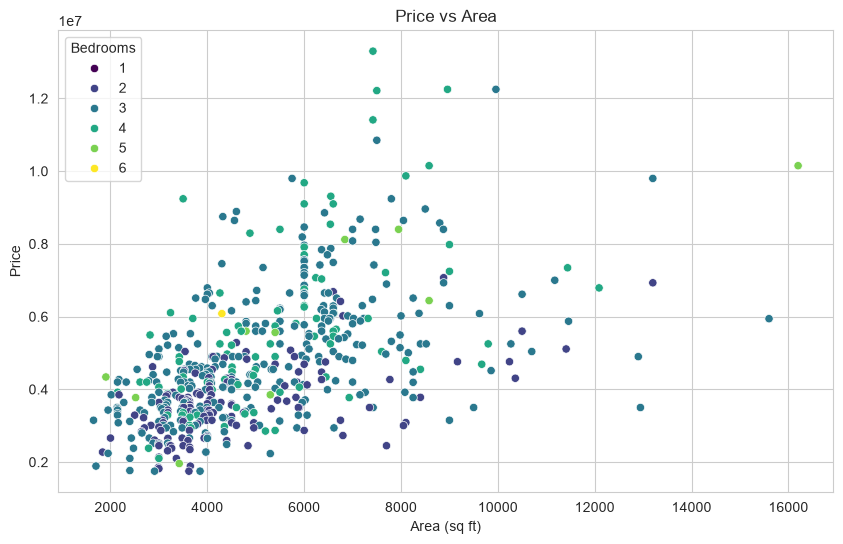

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df, hue='bedrooms', palette='viridis')
plt.title('Price vs Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.legend(title='Bedrooms')
plt.show()

### **2. Distribution of House Price**

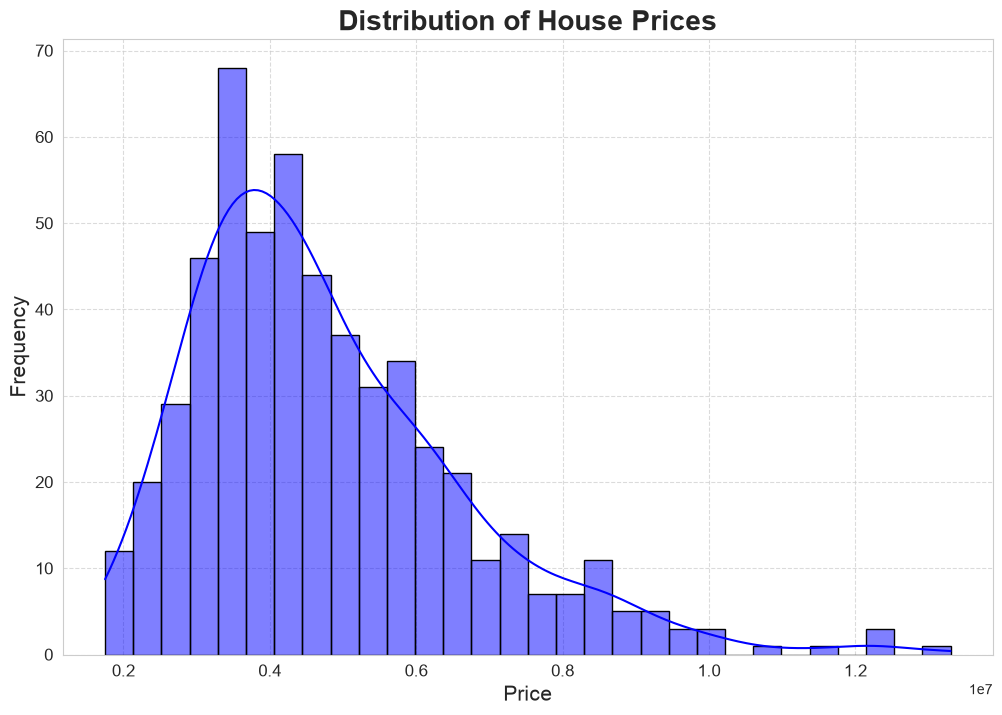

In [44]:
plt.figure(figsize=(12, 8))
sns.histplot(df['price'], bins=30, kde=True, color='blue', edgecolor='black')
plt.title('Distribution of House Prices', fontsize=20, weight='bold')
plt.xlabel('Price', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Adding a grid
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

### **3. Bedroom Bar chart**

/var/folders/yp/_h7ybk210jq0lz14vd_8n95w0000gn/T/ipykernel_3609/1276849908.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bedrooms', data=df, palette='viridis')


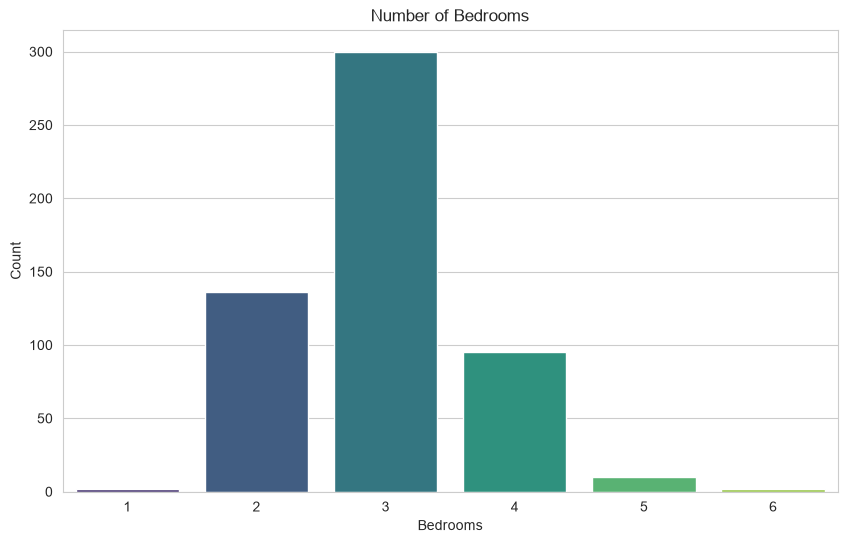

In [45]:
plt.figure(figsize=(10, 6))
sns.countplot(x='bedrooms', data=df, palette='viridis')
plt.title('Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
plt.show()

### **4. Confusion Matrix**

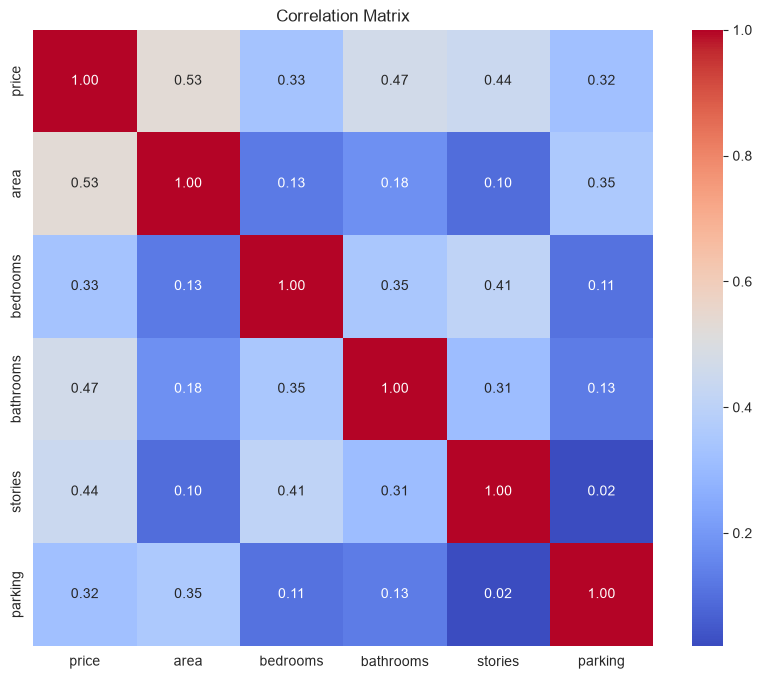

In [46]:
df_numeric = df_cleaned.select_dtypes(include=['number'])
corr_matrix = df_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## **V. Model Development**

### **1. Pick up the features and target variable for the model**

In [47]:
df_model = df_cleaned[['price', 'area', 'bedrooms', 'bathrooms']]
X = df_model[['area', 'bedrooms', 'bathrooms']]
y = df_model['price']
X.shape

(520, 3)

### **2. Train Model**

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 401.79, 369848.16,1045692.94]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['area','bedrooms','bathrooms']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.804e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


### **3. Model Prediction and Evaluation**

In [49]:
y_pred = model.predict(X_test)
y_pred

array([5148105.25419962, 6218517.10136064, 6256075.21825454,
       3388073.19635495, 6408958.26501409, 3431868.00690702,
       3882475.40797008, 6297216.79712549, 4762389.49153919,
       3412180.43152122, 3798100.08488811, 4875093.81302161,
       6298262.87979553, 3299883.89145172, 6378824.22105624,
       4103254.50628783, 4891573.08454538, 5792010.94130371,
       3910396.62495761, 5541856.76191548, 5758821.87841197,
       5932636.47977366, 4344530.74865706, 6568710.31252878,
       3681581.78158444, 5650339.32016372, 6033083.29296648,
       3958611.09529017, 4465066.92448844, 6128262.26025509,
       4111698.03275617, 3589170.71344704, 5489828.30976167,
       6917015.2490633 , 3197428.14199504, 3926672.00577492,
       3044143.30798273, 4376469.8381723 , 4111698.03275617,
       3926672.00577492, 4505245.64976557, 3769974.97719412,
       3958814.98599662, 3171108.07985845, 3882475.40797008,
       4658970.88848869, 3749885.61455556, 4521113.24916996,
       3862386.04533152,

In [50]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-Squared: {r2}")

Mean Squared Error: 1631778839405.5457
R-Squared: 0.47630834571518843


### **4. Result Visualization**

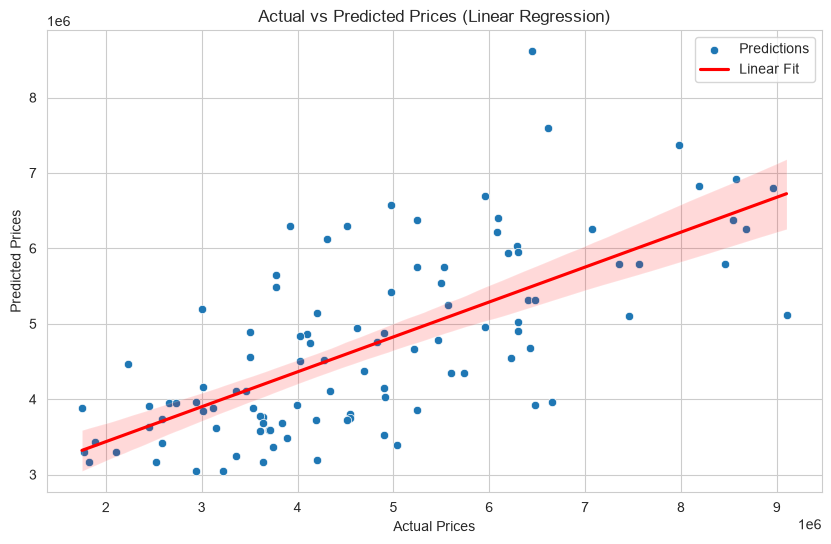

In [51]:
# Chart Actual vs Predicted Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, label='Predictions')
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red', label='Linear Fit')  # Regression Line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Linear Regression)')
plt.legend()
plt.grid(True)
plt.show()

## **VI. Model Improvement**

### **1. One-Hot Encoding**

In [53]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

In [ ]:
df_category = df_cleaned.select_dtypes(include=['object']) #only with object columns
encoded_data = encoder.fit_transform(df_category)
encoded_columns = encoder.get_feature_names_out(df_category.columns.tolist())
df_encoded = pd.DataFrame(encoded_data, columns=encoded_columns)
df_encoded_sklearn = pd.DataFrame(encoded_data, columns=encoded_columns)
df_encoded_sklearn.head()

/var/folders/yp/_h7ybk210jq0lz14vd_8n95w0000gn/T/ipykernel_3609/3275429781.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_category = df_cleaned.select_dtypes(include=['object'])


,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


### **2. Standard Scaler**

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [57]:
df_numeric = df_cleaned.select_dtypes(include=['number'])
standard_data = scaler.fit_transform(df_numeric)
df_standard = pd.DataFrame(standard_data, columns=df_numeric.columns)
df_standard.head()

,price,area,bedrooms,bathrooms,stories,parking
0,2.840371,0.591225,1.445867,-0.565407,0.240573,1.599249
1,2.840371,0.920438,1.445867,1.580662,0.240573,0.409536
2,2.752458,1.962943,0.078865,1.580662,2.557205,1.599249
3,2.708501,-0.176937,0.078865,1.580662,0.240573,1.599249
4,2.686523,0.821674,0.078865,1.580662,0.240573,0.409536


In [58]:
X_new = df_cleaned.drop(columns=['price'])
y_new = df_cleaned["price"]

In [59]:
X_new

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
16,6600,4,2,2,yes,yes,yes,no,yes,1,yes,unfurnished
17,8500,3,2,4,yes,no,no,no,yes,2,no,furnished
18,4600,3,2,2,yes,yes,no,no,yes,2,no,furnished
19,6420,3,2,2,yes,no,no,no,yes,1,yes,semi-furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


### **3. Model Re-train**

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [61]:
# Identify the columns for One-hot Encoding and Standard Scaling
categorical_cols = X_new.select_dtypes(include=['object']).columns
numeric_cols = X_new.select_dtypes(include=['number']).columns

/var/folders/yp/_h7ybk210jq0lz14vd_8n95w0000gn/T/ipykernel_3609/196229214.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_new.select_dtypes(include=['object']).columns


In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# ColumnTransformer to handle different types of columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # Keep the columns that are not processed
)

In [65]:
# Pipeline Creation
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['area','bedrooms','bathrooms',...,'parking','prefarea','furnishingstatus']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of col

In [66]:
y_pred = pipeline.predict(X_test)
y_pred

array([4548552.74512324, 4718831.61563975, 6241633.94755818,
       3334520.62713768, 6523249.2642198 , 2840710.61493341,
       3303147.95175619, 4739048.88790766, 4700656.34649219,
       2829075.54229079, 4503810.4479808 , 4168388.9219128 ,
       5909530.14732999, 3032504.08272343, 7424955.12378814,
       3931118.57885033, 3686374.10892434, 6243326.88039434,
       3547253.38034685, 4642721.98322542, 5588909.40199709,
       6640988.22071833, 5286990.10876547, 5950458.074223  ,
       3258082.02171303, 4670325.8407136 , 6545481.79436101,
       3152008.17073907, 4250865.87101085, 5486772.53082539,
       4030805.24071138, 4193469.37556766, 4250654.86069256,
       6798021.10597714, 4089321.72170577, 3917463.65226565,
       3641082.83755797, 4980156.95226454, 4562881.32148703,
       3725322.65933296, 4205139.77304961, 3898517.27305287,
       4970021.49841949, 3265977.7557487 , 3376807.2527602 ,
       4645585.33976631, 3752201.21795941, 3806834.67341351,
       4638916.94394046,

In [67]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-Squared: {r2}")

Mean Squared Error: 1042591273219.801
R-Squared: 0.6653980702346335


In [68]:
#Save the model
joblib.dump(model, "linear_model.pkl")
print("✅ Model saved as linear_model.pkl")

✅ Model saved as linear_model.pkl
